Nodos: 239
Aristas: 551


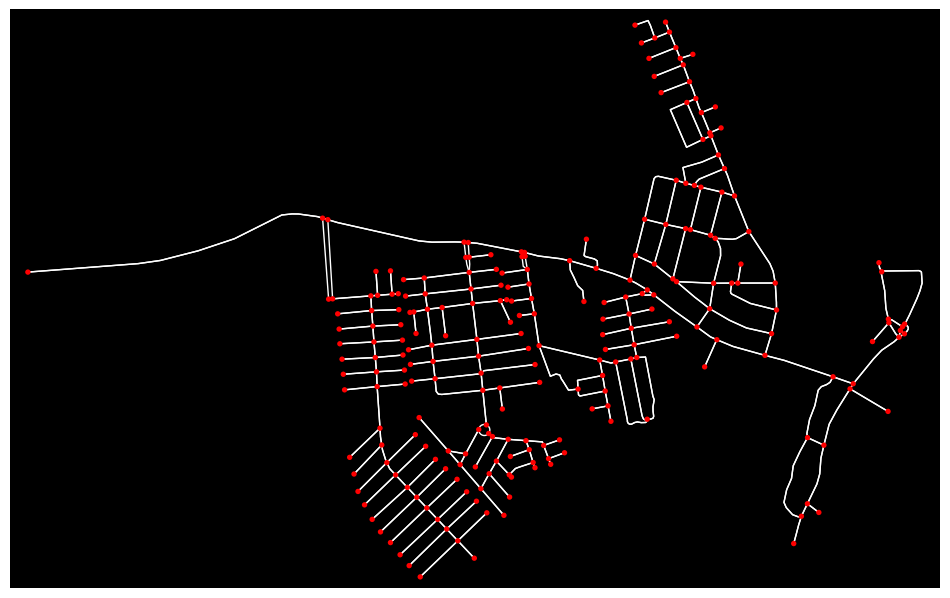

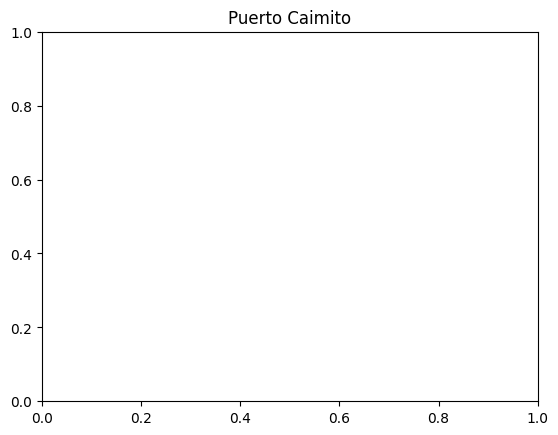

In [1]:
import osmnx as ox
import matplotlib.pyplot as plt

# Coordenadas de Barriada Don Juan, Puerto Caimito
lat, lon = 8.873469020957439, -79.71761518423519

# Reducir el radio a 1000 metros (1 km) 
# para enfocarse solo en la barriada
G = ox.graph_from_point(
    (lat, lon),
    dist=1300,
    network_type="all",     # antes "drive" — ahora incluye residenciales y servidumbres
    simplify=True,
    retain_all=False,        # CLAVE: deja solo el componente conexo, sin islas sueltas
    truncate_by_edge=True,   # no corta calles a la mitad en el borde
)

print(f"Nodos: {len(G.nodes)}")
print(f"Aristas: {len(G.edges)}")

fig, ax = ox.plot_graph(
    G,
    figsize=(12, 12),
    node_color="red",
    node_size=15,
    edge_color="white",
    bgcolor="black"
)
plt.title("Puerto Caimito")
plt.show()

In [2]:
import osmnx as ox
lat, lon = 8.873469020957439, -79.71761518423519

for nt in ["drive", "all"]:
    G = ox.graph_from_point((lat, lon), dist=1300, network_type=nt, retain_all=False)
    print(f"{nt:6} → {len(G.nodes)} nodos, {len(G.edges)} aristas")

# ¿Cuántos edificios tiene OSM en la zona?
edif = ox.features.features_from_point((lat, lon), tags={"building": True}, dist=1300)
print(f"Edificios en OSM: {len(edif)}")

drive  → 228 nodos, 519 aristas
all    → 238 nodos, 549 aristas
Edificios en OSM: 391
